In [26]:
import time
import random
import csv
import matplotlib.pyplot as plt
from phe import paillier
import numpy as np


In [27]:
# --- Experiment setup ---
p = 18446744073709551557
bit_length = p.bit_length()
n_values = [20,100,500,1000,1500]
num_runs = 3  # repeat each method 5 times for stability

# --- Containers for timing and average results ---
times_plain, times_paillier, times_shamir, times_dp = [], [], [], []
errors_dp = []

# NEW: store computed averages for accuracy comparison later
avg_plain_results = {}
avg_paillier_results = {}
avg_shamir_results = {}
avg_dp_results = {}

print("Starting runtime comparison")
print(f"Prime p set to {p.bit_length()} bits")
print(f"n_values = {n_values}")
print(f"Each method runs {num_runs} times per n\n")

values = {}
for c in n_values:
    # Generate c random integers between 0 and 100
    d = [random.randint(0, 100) for _ in range(c)]
    values[c] = d

true_means = {n: sum(v)/len(v) for n, v in values.items()}


Starting runtime comparison
Prime p set to 64 bits
n_values = [20, 100, 500, 1000, 1500]
Each method runs 3 times per n



In [28]:
def plain_avg(values):
    return sum(values) / len(values)
    

In [29]:
# --- 1. Key Generation Phase ---
def paillier_keygen(n_length=4096):
    public_key, private_key = paillier.generate_paillier_keypair(n_length=n_length)
    return public_key, private_key

# --- 2. Encryption Phase ---
def paillier_encrypt(values, public_key):
    # Encrypt each integer using the public key
    encrypted_values = [public_key.encrypt(v) for v in values]
    return encrypted_values

# --- 3. Computation Phase ---
def paillier_compute(encrypted_values):
    # Perform homomorphic addition (encrypted sum)
    encrypted_sum = sum(encrypted_values)
    return encrypted_sum

# --- 4. Decryption Phase ---
def paillier_decrypt(encrypted_sum, private_key, n):
    decrypted_sum = private_key.decrypt(encrypted_sum)
    avg = decrypted_sum / n
    return avg

In [30]:

# --- Helper: Evaluate polynomial at x ---
def compute_modular(coefficients, p, x):
    res = 0
    for coeff in reversed(coefficients):
        res = (res * x + coeff) % p
    return res


# --- Helper: Create n shares from a secret ---
def shamir_share(secret, n, threshold, prime):
    # Random polynomial of degree (threshold - 1)
    coefficients = [secret] + [random.randint(0, prime - 1) for _ in range(threshold - 1)]
    shares = [(i, compute_modular(coefficients, prime, i)) for i in range(1, n + 1)]
    return shares  # list of (x, y) tuples


# --- Helper: Compute Lagrange basis coefficient l_j(0) ---
def compute_l(j, x_values, p):
    x_j = x_values[j]
    numerator = 1
    denominator = 1
    for k, x_k in enumerate(x_values):
        if k != j:
            numerator = (numerator * (-x_k)) % p
            denominator = (denominator * (x_j - x_k)) % p
    denom_inv = pow(denominator, -1, p)
    return (numerator * denom_inv) % p


# --- Main: Compute Shamir-based average ---
def shamir_avg(values, n, p):
    threshold = n // 2 + 1
    phase_times = {}

    # --- Phase 1: Share each secret ---
    start = time.perf_counter()
    all_shares = [shamir_share(secret, n, threshold, p) for secret in values]
    phase_times["share"] = (time.perf_counter() - start) * 1000

    # --- Phase 2: Aggregate shares (local addition at each participant) ---
    start = time.perf_counter()
    aggregated_shares = []
    for i in range(n):
        total_y = sum(share[i][1] for share in all_shares) % p
        aggregated_shares.append((all_shares[0][i][0], total_y))
    phase_times["compute"] = (time.perf_counter() - start) * 1000

    # --- Phase 3: Reconstruct the total sum ---
    start = time.perf_counter()
    x_values = [x for x, _ in aggregated_shares[:threshold]]
    y_values = [y for _, y in aggregated_shares[:threshold]]

    total_sum = 0
    for j in range(threshold):
        l = compute_l(j, x_values, p)
        total_sum = (total_sum + y_values[j] * l) % p

    # unwrap from mod field to regular integer
    if total_sum > p // 2:
        total_sum -= p

    # ✅ Divide by n normally (arithmetic average)
    average = total_sum / len(values)
    phase_times["reconstruct"] = (time.perf_counter() - start) * 1000

    return average, phase_times


In [31]:
def dp_avg(values, sensitivity, epsilon=1.0):
    n = len(values)
    true_avg = sum(values) / n
    noise = np.random.laplace(loc=0, scale = sensitivity / epsilon, size = 1)
    return true_avg + noise

In [32]:


for n in n_values:
    print(f"\n=== Running for n = {n} ===")

    true_mean = sum(values[n]) / n
    true_means[n] = true_mean

    # --- Plain ---
    print("Plain averaging ...", end="")
    runtimes, avg_res = [], []
    for _ in range(num_runs):
        start = time.perf_counter()
        result = plain_avg(values[n])
        elapsed_ms = (time.perf_counter() - start) * 1000
        runtimes.append(elapsed_ms)
        avg_res.append(result)
    avg_time = np.mean(runtimes)
    times_plain.append(avg_time)
    avg_plain_results[n] = avg_res
    print("done")

    # --- Paillier (phase-separated) for this n ---
    print("Paillier averaging...", end="")
    keygen_times, encrypt_times, hom_compute_times, decrypt_times = [], [], [], []
    avg_res = []
    for _ in range(num_runs):
        start = time.perf_counter()
        public_key, private_key = paillier_keygen()
        keygen_times.append((time.perf_counter() - start) * 1000)

        start = time.perf_counter()
        enc = paillier_encrypt(values[n], public_key)
        encrypt_times.append((time.perf_counter() - start) * 1000)

        start = time.perf_counter()
        res = paillier_compute(enc)
        hom_compute_times.append((time.perf_counter() - start) * 1000)

        start = time.perf_counter()
        avg_value = paillier_decrypt(res, private_key, len(values[n]))
        decrypt_times.append((time.perf_counter() - start) * 1000)

        avg_res.append(avg_value)

    times_paillier.append({
        "keygen": np.mean(keygen_times),
        "encrypt": np.mean(encrypt_times),
        "compute": np.mean(hom_compute_times),
        "decrypt": np.mean(decrypt_times)
    })
    avg_paillier_results[n] = avg_res
    print("done")

    # --- Shamir for this n ---
    print("Shamir averaging ...", end="")
    share_times, compute_times_sh, reconstruct_times = [], [], []
    avg_res = []
    for _ in range(num_runs):
        avg_value, t = shamir_avg(values[n], n, p)
        share_times.append(t["share"])
        compute_times_sh.append(t["compute"])
        reconstruct_times.append(t["reconstruct"])
        avg_res.append(avg_value)

    times_shamir.append({
        "share": np.mean(share_times),
        "compute": np.mean(compute_times_sh),
        "reconstruct": np.mean(reconstruct_times)
    })
    avg_shamir_results[n] = avg_res
    print("done")

    # --- Differential Privacy ---
    print("Differential Privacy averaging ...", end="")
    dp_runtimes, dp_avg_res = [], []
    sensitivity = n+1  # or b - a (range of values)
    for _ in range(num_runs):
        start = time.perf_counter()
        dp_result = dp_avg(values[n], sensitivity, epsilon=1.0)
        elapsed_ms = (time.perf_counter() - start) * 1000
        dp_runtimes.append(elapsed_ms)
        dp_avg_res.append(dp_result)

    avg_dp_time = np.mean(dp_runtimes)
    times_dp.append(avg_dp_time)
    avg_dp_results[n] = dp_avg_res
    print("done")





=== Running for n = 20 ===
Plain averaging ...done
Paillier averaging...done
Shamir averaging ...done
Differential Privacy averaging ...done

=== Running for n = 100 ===
Plain averaging ...done
Paillier averaging...done
Shamir averaging ...done
Differential Privacy averaging ...done

=== Running for n = 500 ===
Plain averaging ...done
Paillier averaging...done
Shamir averaging ...done
Differential Privacy averaging ...done

=== Running for n = 1000 ===
Plain averaging ...done
Paillier averaging...done
Shamir averaging ...done
Differential Privacy averaging ...done

=== Running for n = 1500 ===
Plain averaging ...done
Paillier averaging...done
Shamir averaging ...done
Differential Privacy averaging ...done


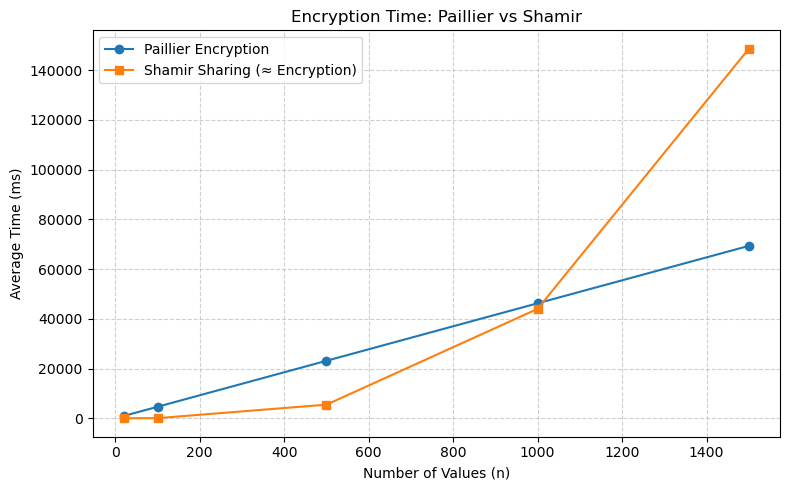

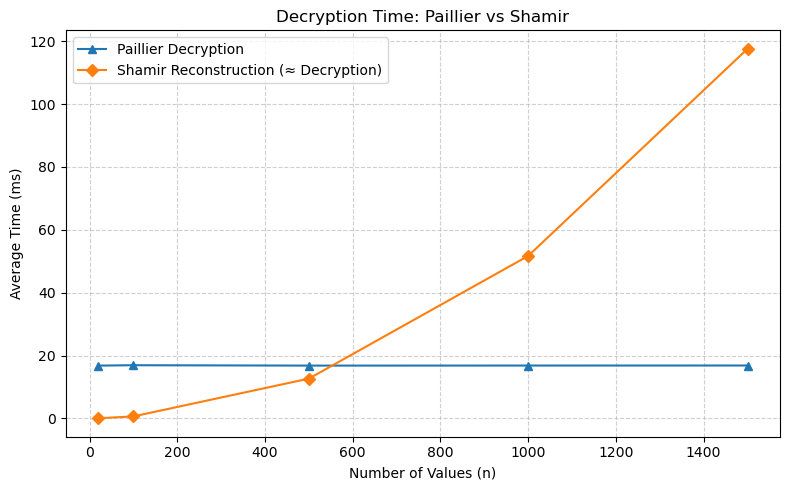

In [ ]:
# --- Compare Paillier vs Shamir: Encryption and Decryption ---

# Extract Paillier phase times
paillier_encrypt_time = [times_paillier[i]["encrypt"] for i in range(len(times_paillier))]
paillier_decrypt_time = [times_paillier[i]["decrypt"] for i in range(len(times_paillier))]

# For Shamir, encryption ≈ sharing phase, decryption ≈ reconstruction phase
shamir_encrypt_time = [times_shamir[i]["share"] for i in range(len(times_shamir))]
shamir_decrypt_time = [times_shamir[i]["reconstruct"] for i in range(len(times_shamir))]


# --- Plot Encryption Time Comparison ---
plt.figure(figsize=(8, 5))
plt.plot(n_values, paillier_encrypt_time, marker='o', label="Paillier Encryption")
plt.plot(n_values, shamir_encrypt_time, marker='s', label="Shamir Sharing (≈ Encryption)")
plt.xlabel("Number of Values (n)")
plt.ylabel("Average Time (ms)")
plt.title("Encryption Time: Paillier vs Shamir")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# --- Plot Decryption Time Comparison ---
plt.figure(figsize=(8, 5))
plt.plot(n_values, paillier_decrypt_time, marker='^', label="Paillier Decryption")
plt.plot(n_values, shamir_decrypt_time, marker='D', label="Shamir Reconstruction (≈ Decryption)")
plt.xlabel("Number of Values (n)")
plt.ylabel("Average Time (ms)")
plt.title("Decryption Time: Paillier vs Shamir")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

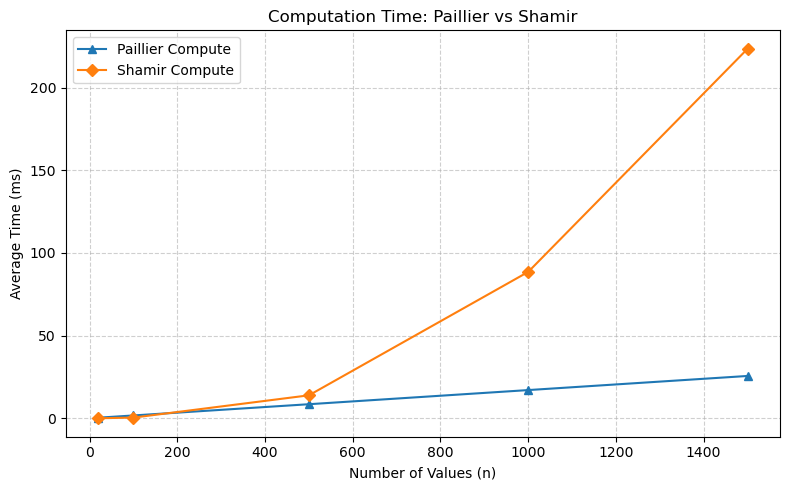

In [42]:
shamir_compute_time = [times_shamir[i]["compute"] for i in range(len(times_shamir))]
paillier_compute_time = [times_paillier[i]["compute"] for i in range(len(times_paillier))]
# --- Plot Compute Time Comparison ---
plt.figure(figsize=(8, 5))
plt.plot(n_values, paillier_compute_time, marker='^', label="Paillier Compute")
plt.plot(n_values, shamir_compute_time, marker='D', label="Shamir Compute")
plt.xlabel("Number of Values (n)")
plt.ylabel("Average Time (ms)")
plt.title("Computation Time: Paillier vs Shamir")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

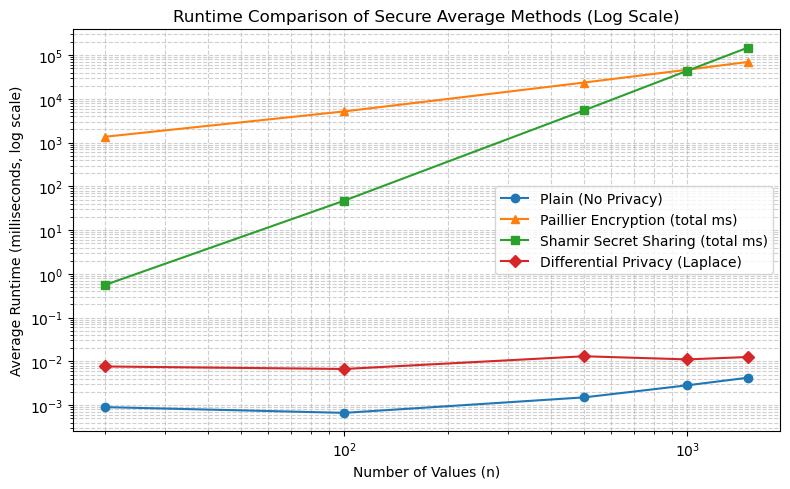

Plot displayed. Done.


In [35]:
# --- Compare the total running time  ---
plt.figure(figsize=(8, 5))

# For plotting we need numeric values; extract a representative Paillier total time and Shamir total time
paillier_totals = [sum(times_paillier[i].values()) for i in range(len(times_paillier))]
shamir_totals = [sum(times_shamir[i].values()) for i in range(len(times_shamir))]

plt.plot(n_values, times_plain, marker='o', label="Plain (No Privacy)")
plt.plot(n_values, paillier_totals, marker='^', label="Paillier Encryption (total ms)")
plt.plot(n_values, shamir_totals, marker='s', label="Shamir Secret Sharing (total ms)")
plt.plot(n_values, times_dp, marker='D', label="Differential Privacy (Laplace)")

plt.xlabel("Number of Values (n)")
plt.ylabel("Average Runtime (milliseconds, log scale)")
plt.title("Runtime Comparison of Secure Average Methods (Log Scale)")

# 🔹 Apply logarithmic scale to y-axis
plt.yscale("log")
plt.xscale("log")

plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

print("Plot displayed. Done.")


In [ ]:
# --- Accuracy Analysis (using MSE instead of MAE) ---
mse_plain, mse_paillier, mse_shamir, mse_dp = [], [], [], []

def compute_mse(avg_results, true_means):
    mse_results = {}
    for n, estimates in avg_results.items():
        true_val = true_means[n]   # scalar true mean for that n
        mse_results[n] = np.mean([(e - true_val) ** 2 for e in estimates])
    return mse_results



=== Accuracy Analysis (MSE) ===


In [37]:
mse_plain = compute_mse(avg_plain_results, true_means)
mse_paillier = compute_mse(avg_paillier_results, true_means)
mse_shamir = compute_mse(avg_shamir_results, true_means)
mse_dp = compute_mse(avg_dp_results, true_means)


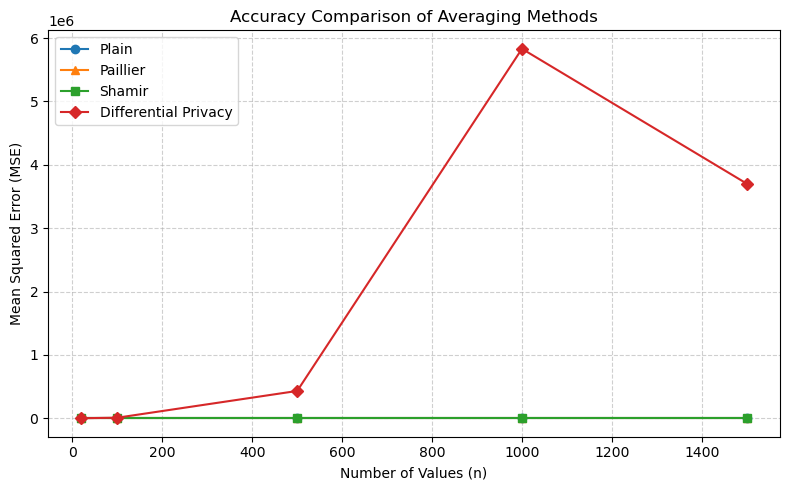

In [40]:
plt.figure(figsize=(8,5))
plt.plot(n_values, [mse_plain[n] for n in n_values], marker='o', label='Plain')
plt.plot(n_values, [mse_paillier[n] for n in n_values], marker='^', label='Paillier')
plt.plot(n_values, [mse_shamir[n] for n in n_values], marker='s', label='Shamir')
plt.plot(n_values, [mse_dp[n] for n in n_values], marker='D', label='Differential Privacy')
plt.xlabel("Number of Values (n)")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Accuracy Comparison of Averaging Methods")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [43]:
# --- Save results ---
with open('runtime_results.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    # save results in milliseconds (paillier/shamir stored as dicts)
    writer.writerow(['n', 'plain_ms', 'paillier_ms', 'shamir_ms', 'dp_ms'])
    for i, n in enumerate(n_values):
        writer.writerow([n, times_plain[i], times_paillier[i], times_shamir[i], times_dp[i]])

print("\nWrote runtime_results.csv")
print("Results (n, plain_ms, paillier_ms, shamir_ms, dp_ms):")
for i, n in enumerate(n_values):
    print(f"{n}: {times_plain[i]:.2f}ms, {times_paillier[i]}, {times_shamir[i]}, {times_dp[i]}")


Wrote runtime_results.csv
Results (n, plain_ms, paillier_ms, shamir_ms, dp_ms):
20: 0.00ms, {'keygen': np.float64(416.9698573338489), 'encrypt': np.float64(927.6982070102046), 'compute': np.float64(0.35606068558990955), 'decrypt': np.float64(16.785538289695978)}, {'share': np.float64(0.49523869529366493), 'compute': np.float64(0.022274985288580258), 'reconstruct': np.float64(0.038301960254708924)}, 0.0076429763187964754
100: 0.00ms, {'keygen': np.float64(541.3840549687544), 'encrypt': np.float64(4621.320703610157), 'compute': np.float64(1.7114856746047735), 'decrypt': np.float64(16.905259961883228)}, {'share': np.float64(46.37467496407529), 'compute': np.float64(0.4231344598035018), 'reconstruct': np.float64(0.6263020137945811)}, 0.006695355599125226
500: 0.00ms, {'keygen': np.float64(535.8489777427167), 'encrypt': np.float64(23109.691567718983), 'compute': np.float64(8.508736888567606), 'decrypt': np.float64(16.7868936744829)}, {'share': np.float64(5467.1366059531765), 'compute': np.

In [45]:
# --- Save average results (mean per n) ---
with open('avg_results.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['n', 'plain_avg', 'paillier_avg', 'shamir_avg', 'dp_avg'])

    for n in n_values:
        plain_mean = np.mean(avg_plain_results[n])
        paillier_mean = np.mean(avg_paillier_results[n])
        shamir_mean = np.mean(avg_shamir_results[n])
        dp_mean = np.mean(avg_dp_results[n])

        writer.writerow([n, plain_mean, paillier_mean, shamir_mean, dp_mean])

print("\n✅ Wrote avg_results.csv successfully!")
print("Results (n, plain_avg, paillier_avg, shamir_avg, dp_avg):")
for n in n_values:
    print(f"{n}: {np.mean(avg_plain_results[n]):.4f}, "
          f"{np.mean(avg_paillier_results[n]):.4f}, "
          f"{np.mean(avg_shamir_results[n]):.4f}, "
          f"{np.mean(avg_dp_results[n]):.4f}")


✅ Wrote avg_results.csv successfully!
Results (n, plain_avg, paillier_avg, shamir_avg, dp_avg):
20: 50.7500, 50.7500, 50.7500, 58.7806
100: 49.2500, 49.2500, 49.2500, 118.9244
500: 51.8360, 51.8360, 51.8360, -232.2520
1000: 50.0740, 50.0740, 50.0740, -1211.6541
1500: 49.1053, 49.1053, 49.1053, 954.1576
